In [ ]:
!pip install cupy-cuda12x
!pip install pynvjpeg
!pip install matplotlib pandas

  Preparing metadata (setup.py) ... done
  Created wheel for pynvjpeg: filename=pynvjpeg-0.0.13-cp312-cp312-linux_x86_64.whl size=67780 sha256=ab91d72d828aee042c0fbec022028dfed95657114a91017c219ec75ce58b3d3b
  Stored in directory: /root/.cache/pip/wheels/78/56/5d/858677710ebb574666901c0e83c0f92a298c8bec5f3f9111a2
Successfully built pynvjpeg


In [4]:
!pip install cupy-cuda12x
!pip install pynvjpeg
!pip install matplotlib pandas
!pip install kagglehub

In [5]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download(
    "alihasnainch/fruits-dataset-for-classification"
)

print("Dataset Path:", path)

Using Colab cache for faster access to the 'fruits-dataset-for-classification' dataset.
Dataset Path: /kaggle/input/fruits-dataset-for-classification


In [8]:
import os

image_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, file))

print("Total Images Found:", len(image_files))

# Use first 15 images for assignment
image_files = image_files[:1655]

print("Images selected:", len(image_files))

Total Images Found: 1655
Images selected: 1655


In [9]:
import cv2
import time
import numpy as np

cpu_times = []

start_total = time.time()

for img_path in image_files:

    start = time.time()

    # Load image using OpenCV
    img = cv2.imread(img_path)

    # Resize image
    resized = cv2.resize(img, (512, 512))

    # Convert to grayscale
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    end = time.time()

    cpu_times.append(end - start)

cpu_total_time = time.time() - start_total
cpu_avg_time = np.mean(cpu_times)

print("CPU Total Time:", cpu_total_time)
print("CPU Avg Time/Image:", cpu_avg_time)

CPU Total Time: 6.977872133255005
CPU Avg Time/Image: 0.004213827398248309


In [13]:
!apt-get update
!apt-get install -y build-essential
!apt-get install -y cuda-toolkit-12-1

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,293 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,913 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricte

In [14]:
!git clone https://github.com/UsingNet/nvjpeg-python.git

Cloning into 'nvjpeg-python'...
remote: Enumerating objects: 238, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 238 (delta 21), reused 20 (delta 20), pack-reused 208 (from 1)
Receiving objects: 100% (238/238), 405.47 KiB | 9.65 MiB/s, done.
Resolving deltas: 100% (123/123), done.


In [15]:
%cd nvjpeg-python

!python setup.py install

/content/nvjpeg-python
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` and ``easy_install``.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        Se

In [16]:
from nvjpeg import NvJpeg

nj = NvJpeg()

print("nvJPEG initialized successfully")

nvJPEG initialized successfully


In [17]:
from nvjpeg import NvJpeg
import cupy as cp
import cv2
import time
import numpy as np

nj = NvJpeg()

gpu_times = []

gpu_total_start = time.time()

for img_path in image_files:

    start = time.time()

    # Decode JPEG using nvJPEG
    img = nj.read(img_path)

    # Move image to GPU
    gpu_img = cp.asarray(img)

    # Resize
    resized_cpu = cv2.resize(
        cp.asnumpy(gpu_img),
        (512, 512)
    )

    resized_gpu = cp.asarray(resized_cpu)

    # Grayscale conversion on GPU
    gray_gpu = (
        0.299 * resized_gpu[:, :, 2] +
        0.587 * resized_gpu[:, :, 1] +
        0.114 * resized_gpu[:, :, 0]
    )

    result = cp.asnumpy(gray_gpu).astype(np.uint8)

    end = time.time()

    gpu_times.append(end - start)

gpu_total_time = time.time() - gpu_total_start
gpu_avg_time = np.mean(gpu_times)

print("GPU Total Time:", gpu_total_time)
print("GPU Avg Time:", gpu_avg_time)

GPU Total Time: 7.515343427658081
GPU Avg Time: 0.004538084877221606


In [18]:
speedup = cpu_total_time / gpu_total_time

print("Speedup:", speedup)

Speedup: 0.9284834685764238


In [19]:
import pandas as pd

results = pd.DataFrame({
    "Pipeline": ["CPU", "GPU (nvJPEG)"],
    "Total Time": [cpu_total_time, gpu_total_time],
    "Average Time/Image": [cpu_avg_time, gpu_avg_time]
})

results

,Pipeline,Total Time,Average Time/Image
0,CPU,6.977872,0.004214
1,GPU (nvJPEG),7.515343,0.004538


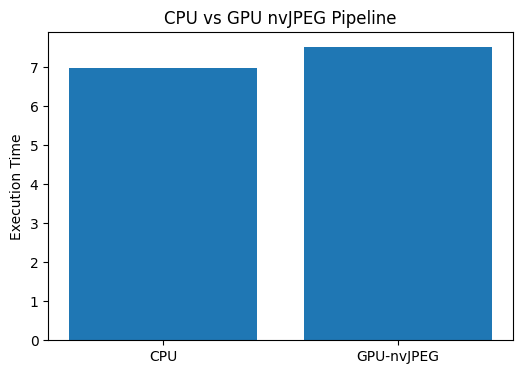

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    ["CPU", "GPU-nvJPEG"],
    [cpu_total_time, gpu_total_time]
)

plt.ylabel("Execution Time")
plt.title("CPU vs GPU nvJPEG Pipeline")

plt.show()

# Question 2

In [21]:
import os

image_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, file))

print("Images Found:", len(image_files))

img_path = image_files[0]

print("Selected Image:", img_path)

Images Found: 1655
Selected Image: /kaggle/input/fruits-dataset-for-classification/rotten_peaches_done/rotten_peach_97.jpg


In [22]:
from nvjpeg import NvJpeg
import cupy as cp
import numpy as np

nj = NvJpeg()

# Decode JPEG
img = nj.read(img_path)

print("Image Shape:", img.shape)

Image Shape: (300, 300, 3)


In [23]:
import cv2

resolutions = [
    (256, 256),
    (1024, 1024)
]

In [24]:
direct_results = []

for size in resolutions:

    resized = cv2.resize(img, size)

    gray_direct = cv2.cvtColor(
        resized,
        cv2.COLOR_BGR2GRAY
    )

    direct_results.append(gray_direct)

print("Direct grayscale completed")

Direct grayscale completed


In [25]:
manual_results = []

for size in resolutions:

    resized = cv2.resize(img, size)

    # Convert to GPU array
    gpu_img = cp.asarray(resized)

    # Manual grayscale formula
    gray_manual = (
        0.299 * gpu_img[:, :, 2] +
        0.587 * gpu_img[:, :, 1] +
        0.114 * gpu_img[:, :, 0]
    )

    result = cp.asnumpy(gray_manual).astype(np.uint8)

    manual_results.append(result)

print("Manual grayscale completed")

Manual grayscale completed


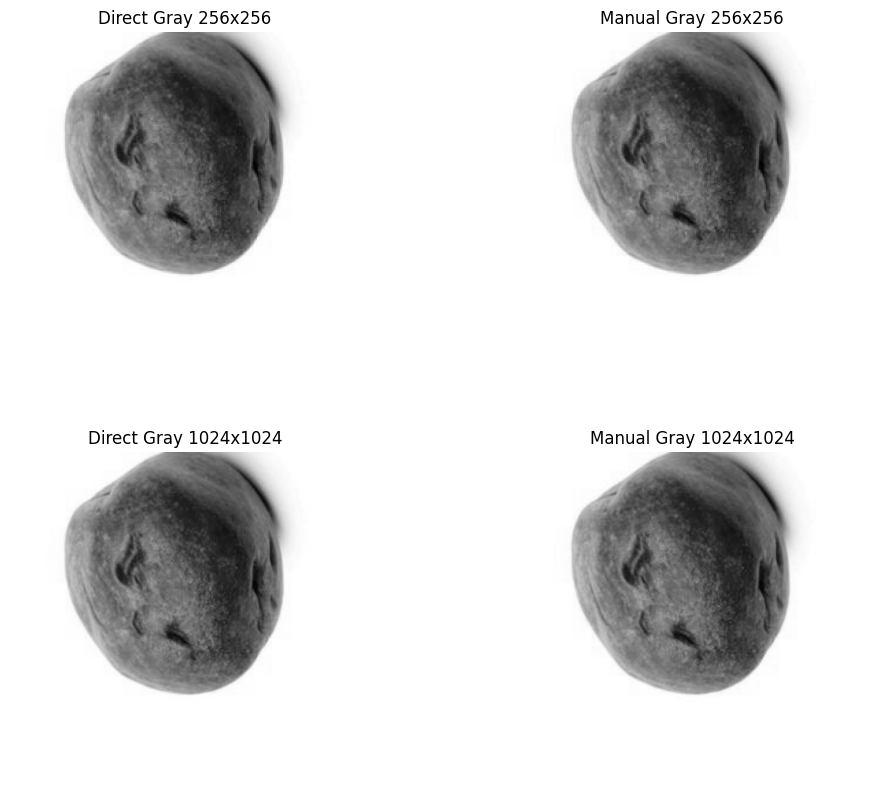

In [26]:
import matplotlib.pyplot as plt

titles = [
    "Direct Gray 256x256",
    "Manual Gray 256x256",
    "Direct Gray 1024x1024",
    "Manual Gray 1024x1024"
]

images = [
    direct_results[0],
    manual_results[0],
    direct_results[1],
    manual_results[1]
]

plt.figure(figsize=(12,10))

for i in range(4):

    plt.subplot(2,2,i+1)

    plt.imshow(images[i], cmap='gray')

    plt.title(titles[i])

    plt.axis("off")

plt.show()

In [27]:
import time

for size in resolutions:

    resized = cv2.resize(img, size)

    # Direct grayscale timing
    start = time.time()

    gray_direct = cv2.cvtColor(
        resized,
        cv2.COLOR_BGR2GRAY
    )

    direct_time = time.time() - start

    # Manual grayscale timing
    start = time.time()

    gpu_img = cp.asarray(resized)

    gray_manual = (
        0.299 * gpu_img[:, :, 2] +
        0.587 * gpu_img[:, :, 1] +
        0.114 * gpu_img[:, :, 0]
    )

    cp.asnumpy(gray_manual)

    manual_time = time.time() - start

    print(f"\nResolution: {size}")
    print("Direct Gray Time:", direct_time)
    print("Manual Gray Time:", manual_time)


Resolution: (256, 256)
Direct Gray Time: 6.437301635742188e-05
Manual Gray Time: 0.00093841552734375

Resolution: (1024, 1024)
Direct Gray Time: 0.0007343292236328125
Manual Gray Time: 0.0038254261016845703


In [28]:
cv2.imwrite("direct_gray_256.jpg", direct_results[0])
cv2.imwrite("manual_gray_256.jpg", manual_results[0])

cv2.imwrite("direct_gray_1024.jpg", direct_results[1])
cv2.imwrite("manual_gray_1024.jpg", manual_results[1])

print("All outputs saved")

All outputs saved


# Question 3

In [15]:
import os

image_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, file))

print("Total Images:", len(image_files))

# Use 200 images for better GPU benchmarking
image_files = image_files[:1655]

print("Selected Images:", len(image_files))

Total Images: 1655
Selected Images: 1655


In [16]:
batch_sizes = [8, 16, 32,64,128]

resolutions = [
    (256, 256),
    (512, 512)
]

In [17]:
import cv2
import cupy as cp
import numpy as np
import time

hybrid_results = []

for batch_size in batch_sizes:

    for resolution in resolutions:

        start_total = time.time()

        for i in range(0, len(image_files), batch_size):

            batch = image_files[i:i+batch_size]

            processed = []

            for img_path in batch:

                # CPU Decode
                img = cv2.imread(img_path)

                # CPU Resize
                resized = cv2.resize(img, resolution)

                # Transfer to GPU
                gpu_img = cp.asarray(resized)

                # Normalize on GPU
                normalized = gpu_img / 255.0

                processed.append(normalized)

        total_time = time.time() - start_total

        throughput = len(image_files) / total_time

        hybrid_results.append([
            batch_size,
            resolution,
            total_time,
            throughput
        ])

        print(
            f"Hybrid | Batch={batch_size} | "
            f"Resolution={resolution} | "
            f"Time={total_time:.4f} | "
            f"Throughput={throughput:.2f}"
        )

Hybrid | Batch=8 | Resolution=(256, 256) | Time=2.8171 | Throughput=587.49
Hybrid | Batch=8 | Resolution=(512, 512) | Time=3.5517 | Throughput=465.98
Hybrid | Batch=16 | Resolution=(256, 256) | Time=3.1044 | Throughput=533.11
Hybrid | Batch=16 | Resolution=(512, 512) | Time=3.4041 | Throughput=486.17
Hybrid | Batch=32 | Resolution=(256, 256) | Time=2.8235 | Throughput=586.15
Hybrid | Batch=32 | Resolution=(512, 512) | Time=3.7025 | Throughput=447.00
Hybrid | Batch=64 | Resolution=(256, 256) | Time=2.9486 | Throughput=561.29
Hybrid | Batch=64 | Resolution=(512, 512) | Time=3.3654 | Throughput=491.77
Hybrid | Batch=128 | Resolution=(256, 256) | Time=2.7766 | Throughput=596.06
Hybrid | Batch=128 | Resolution=(512, 512) | Time=3.9137 | Throughput=422.87


In [33]:
!pip install nvidia-dali-cuda120

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/pynvjpeg-0.0.13-py3.12-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.8/420.8 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 53.3 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 26.1
    Uninstalling packaging-26.1:
      Successfully uninstalled packaging-26.1


In [1]:
from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types

In [18]:
class DALIPipeline(Pipeline):

    def __init__(
        self,
        batch_size,
        num_threads,
        device_id,
        image_dir,
        resolution
    ):

        super().__init__(
            batch_size,
            num_threads,
            device_id
        )

        self.input = fn.readers.file(
            file_root=image_dir,
            random_shuffle=True
        )

        self.resolution = resolution

    def define_graph(self):

        jpegs, labels = self.input

        images = fn.decoders.image(
            jpegs,
            device="mixed",
            output_type=types.RGB
        )

        resized = fn.resize(
            images,
            resize_x=self.resolution[0],
            resize_y=self.resolution[1]
        )

        normalized = fn.crop_mirror_normalize(
            resized,
            dtype=types.FLOAT,
            output_layout="HWC"
        )

        return normalized

In [19]:
dali_results = []

for batch_size in batch_sizes:

    for resolution in resolutions:

        pipe = DALIPipeline(
            batch_size=batch_size,
            num_threads=2,
            device_id=0,
            image_dir=path,
            resolution=resolution
        )

        pipe.build()

        start_total = time.time()

        iterations = len(image_files) // batch_size

        for _ in range(iterations):

            pipe.run()

        total_time = time.time() - start_total

        throughput = len(image_files) / total_time

        dali_results.append([
            batch_size,
            resolution,
            total_time,
            throughput
        ])

        print(
            f"DALI | Batch={batch_size} | "
            f"Resolution={resolution} | "
            f"Time={total_time:.4f} | "
            f"Throughput={throughput:.2f}"
        )

DALI | Batch=8 | Resolution=(256, 256) | Time=1.3097 | Throughput=1263.64
DALI | Batch=8 | Resolution=(512, 512) | Time=1.3067 | Throughput=1266.60
DALI | Batch=16 | Resolution=(256, 256) | Time=1.2815 | Throughput=1291.41
DALI | Batch=16 | Resolution=(512, 512) | Time=1.2860 | Throughput=1286.93
DALI | Batch=32 | Resolution=(256, 256) | Time=1.2037 | Throughput=1374.95
DALI | Batch=32 | Resolution=(512, 512) | Time=1.1994 | Throughput=1379.91
DALI | Batch=64 | Resolution=(256, 256) | Time=1.2593 | Throughput=1314.25
DALI | Batch=64 | Resolution=(512, 512) | Time=1.3024 | Throughput=1270.75
DALI | Batch=128 | Resolution=(256, 256) | Time=1.1562 | Throughput=1431.42
DALI | Batch=128 | Resolution=(512, 512) | Time=1.0954 | Throughput=1510.89


In [20]:
import pandas as pd

hybrid_df = pd.DataFrame(
    hybrid_results,
    columns=[
        "Batch Size",
        "Resolution",
        "Total Time",
        "Throughput"
    ]
)

dali_df = pd.DataFrame(
    dali_results,
    columns=[
        "Batch Size",
        "Resolution",
        "Total Time",
        "Throughput"
    ]
)

print("\nHybrid Pipeline Results")
display(hybrid_df)

print("\nDALI Pipeline Results")
display(dali_df)


Hybrid Pipeline Results


,Batch Size,Resolution,Total Time,Throughput
0,8,"(256, 256)",2.817080,587.487848
1,8,"(512, 512)",3.551676,465.977185
2,16,"(256, 256)",3.104414,533.111969
3,16,"(512, 512)",3.404145,486.172039
4,32,"(256, 256)",2.823513,586.149234
5,32,"(512, 512)",3.702480,446.997650
6,64,"(256, 256)",2.948581,561.287032
7,64,"(512, 512)",3.365363,491.774569
8,128,"(256, 256)",2.776576,596.057869
9,128,"(512, 512)",3.913728,422.870496



DALI Pipeline Results


,Batch Size,Resolution,Total Time,Throughput
0,8,"(256, 256)",1.309712,1263.636880
1,8,"(512, 512)",1.306653,1266.595089
2,16,"(256, 256)",1.281550,1291.405009
3,16,"(512, 512)",1.286004,1286.932406
4,32,"(256, 256)",1.203678,1374.952832
5,32,"(512, 512)",1.199353,1379.910143
6,64,"(256, 256)",1.259273,1314.250559
7,64,"(512, 512)",1.302382,1270.748994
8,128,"(256, 256)",1.156194,1431.420714
9,128,"(512, 512)",1.095383,1510.886500


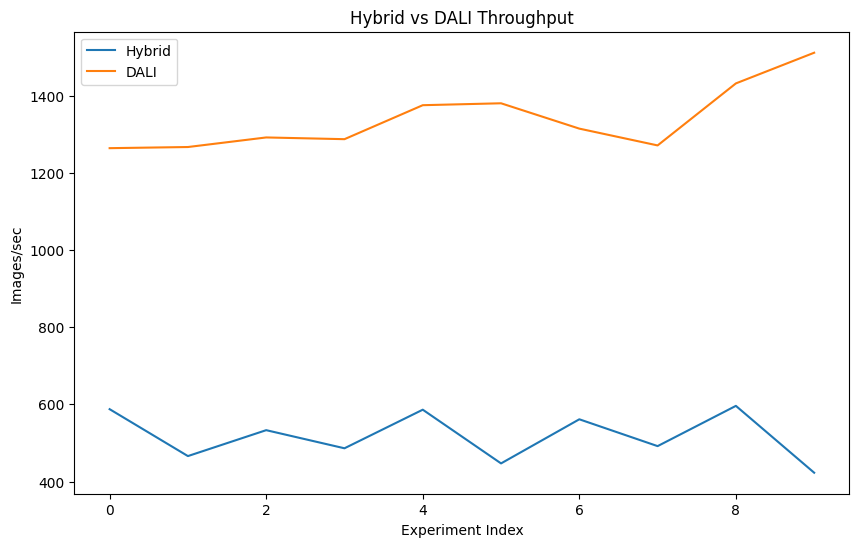

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    hybrid_df["Throughput"],
    label="Hybrid"
)

plt.plot(
    dali_df["Throughput"],
    label="DALI"
)

plt.xlabel("Experiment Index")
plt.ylabel("Images/sec")
plt.title("Hybrid vs DALI Throughput")

plt.legend()

plt.show()

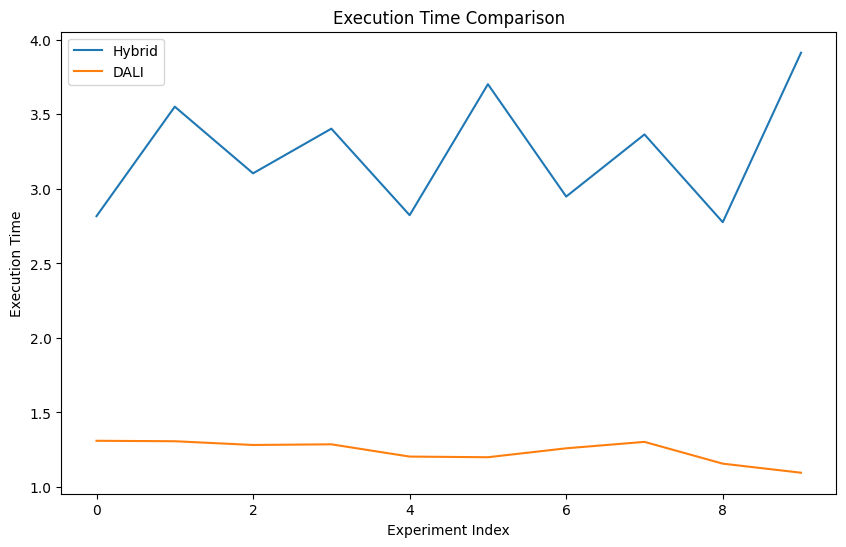

In [22]:
plt.figure(figsize=(10,6))

plt.plot(
    hybrid_df["Total Time"],
    label="Hybrid"
)

plt.plot(
    dali_df["Total Time"],
    label="DALI"
)

plt.xlabel("Experiment Index")
plt.ylabel("Execution Time")
plt.title("Execution Time Comparison")

plt.legend()

plt.show()

In [23]:
hybrid_df.to_csv("hybrid_results.csv", index=False)
dali_df.to_csv("dali_results.csv", index=False)

print("Results saved")

Results saved
